## **Birthday problem  🎂**

# • The birthday problem asks for the probability that, in a set of n randomly chosen people, at least two share the same birthday.
# • For different n, compute the probability empirically.
# • Compare it to its theoretical value.


 ---------------------------------
#Theoretial Probability of at least TWO People with the same Birthday

In [18]:
Nos = 4 # NO of people in the group
Pn=1

for i in range(Nos):
  #print(i)
  Pn = (Pn * ((365-i)/365))
  print(i, Pn)

print(1-Pn)





0 1.0
1 0.9972602739726028
2 0.9917958341152187
3 0.9836440875334498
0.016355912466550215


# Random Dataset with 100 People and their Birthdays in MM-DD format

In [4]:
import pandas as pd
import random
import os

# File configuration
file_name = 'names_birthdays.csv'
file_path = f'/content/{file_name}'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)

    # 1. Import random number of rows
    num_to_sample = Nos
    n = min(num_to_sample, len(df))
    random_df = df.sample(n=n).copy()

    # 2. Sort the data frame by birthdays
    # Note: Sorting assumes 'Birthday' column exists as shown in previous state
    random_df = random_df.sort_values(by='Birthday')

    print(f'Randomly sampled and sorted {n} rows:')
    display(random_df)

    # 3. Counts the number of instances and the probability
    stats_df = random_df['Birthday'].value_counts().reset_index()
    stats_df.columns = ['Birthday', 'Count']
    stats_df['Probability'] = stats_df['Count'] / n

    print('\nBirthday Frequency and Probability in Sample:')
    display(stats_df)
else:
    print(f'Please upload {file_name} to the Colab file explorer first.')

Randomly sampled and sorted 30 rows:


,Name,Birthday
92,Nicholas Diaz,01-15
25,Melissa Campbell,01-22
58,Paul Wilson,02-04
70,Rebecca Evans,02-13
61,Sandra Powell,02-19
85,Dennis Adams,02-22
48,Jonathan Bryant,03-30
7,Nicole Cook,04-13
65,Karen Hill,04-16
3,Mark Martinez,04-17



Birthday Frequency and Probability in Sample:


,Birthday,Count,Probability
0,09-28,2,0.066667
1,07-09,2,0.066667
2,01-15,1,0.033333
3,01-22,1,0.033333
4,02-19,1,0.033333
5,02-22,1,0.033333
6,03-30,1,0.033333
7,04-13,1,0.033333
8,04-16,1,0.033333
9,04-17,1,0.033333


# Visits to X number of rooms with the given number of people where the probability is evident

In [5]:
import random
from datetime import date, timedelta
from collections import Counter

def generate_birthdays(n: int) -> list[str]:
    """Generate n uniformly distributed birthdays (dd.mm) using a leap year base."""
    start = date(2000, 1, 1)
    # leap year -> 366 days incl. 29.02
    return [
        (start + timedelta(days=random.randint(0, 365))).strftime("%d.%m")
        for _ in range(n)
    ]

def analyse_single(birthdays: list[str]) -> dict:
    """Return collision stats for one draw."""
    counts = Counter(birthdays)
    shared = {day: cnt for day, cnt in counts.items() if cnt > 1}
    return {
        "unique_dates": len(counts),
        "dates_with_collision": len(shared),
        "persons_sharing_a_date": sum(shared.values()),
        "collision_detail": dict(sorted(shared.items(), key=lambda x: x[1], reverse=True)),
    }

def run(n: int, k: int) -> None:
    experiments_with_collision = 0
    total_colliding_dates = 0
    total_persons_sharing = 0
    collision_counts: list[int] = []

    for _ in range(k):
        birthdays = generate_birthdays(n)
        stats = analyse_single(birthdays)
        if stats["dates_with_collision"] > 0:
            experiments_with_collision += 1
            total_colliding_dates += stats["dates_with_collision"]
            total_persons_sharing += stats["persons_sharing_a_date"]
            collision_counts.append(stats["dates_with_collision"])

    pct = 100 * experiments_with_collision / k

    print(f"\n{'='*50}")
    print(f" Birthday collision simulation")
    print(f" persons per draw n={n} repeats k={k}")
    print(f"{'='*50}")
    print(f" Experiments with >=1 collision : {experiments_with_collision} / {k} ({pct:.1f}%)")

    if experiments_with_collision > 0:
        avg_dates = total_colliding_dates / experiments_with_collision
        avg_persons = total_persons_sharing / experiments_with_collision
        print(f" Avg colliding dates per hit : {avg_dates:.2f}")
        print(f" Avg persons sharing a date : {avg_persons:.2f}")

    dist = Counter(collision_counts)
    print(f"\n Distribution of colliding-date counts")
    print(f" (among {experiments_with_collision} experiments that had a collision):")
    for cnt in sorted(dist):
        bar = "X" * min(dist[cnt] * 40 // max(dist.values()), 40)
        print(f" {cnt:3d} shared date(s) -> {dist[cnt]:6d}x {bar}")

    print(f"{'='*50}\n")

if __name__ == "__main__":
    n = Nos
    k = int(input("Enter number of repetitions (k): "))
    run(n, k)

Enter number of repetitions (k): 100

 Birthday collision simulation
 persons per draw n=30 repeats k=100
 Experiments with >=1 collision : 69 / 100 (69.0%)
 Avg colliding dates per hit : 1.64
 Avg persons sharing a date : 3.33

 Distribution of colliding-date counts
 (among 69 experiments that had a collision):
   1 shared date(s) ->     37x XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   2 shared date(s) ->     22x XXXXXXXXXXXXXXXXXXXXXXX
   3 shared date(s) ->      8x XXXXXXXX
   4 shared date(s) ->      2x XX



Distribution of Probaility and the Group size

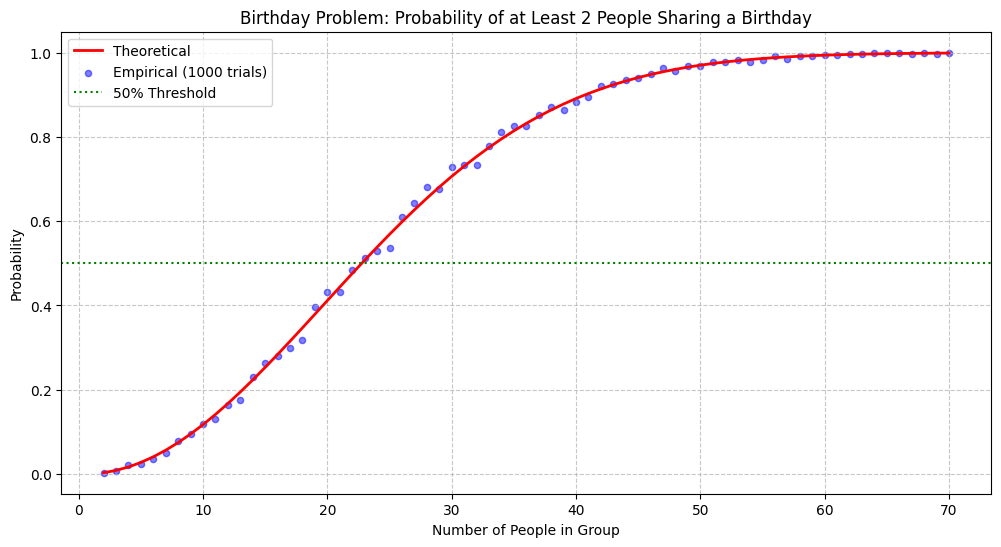

In [6]:
import matplotlib.pyplot as plt
import random
from datetime import date, timedelta

def get_empirical_prob(n, trials=1000):
    collisions = 0
    for _ in range(trials):
        birthdays = [random.randint(1, 365) for _ in range(n)]
        if len(birthdays) != len(set(birthdays)):
            collisions += 1
    return collisions / trials

def get_theoretical_prob(n):
    prob_no_collision = 1.0
    for i in range(n):
        prob_no_collision *= (365 - i) / 365
    return 1 - prob_no_collision

# Parameters
group_sizes = list(range(2, 71))
empirical_vals = [get_empirical_prob(n) for n in group_sizes]
theoretical_vals = [get_theoretical_prob(n) for n in group_sizes]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(group_sizes, theoretical_vals, label="Theoretical", color="red", linewidth=2)
plt.scatter(group_sizes, empirical_vals, label="Empirical (1000 trials)", color="blue", alpha=0.5, s=20)

plt.title("Birthday Problem: Probability of at Least 2 People Sharing a Birthday")
plt.xlabel("Number of People in Group")
plt.ylabel("Probability")
plt.grid(True, linestyle="--", alpha=0.7)
plt.axhline(0.5, color="green", linestyle=":", label="50% Threshold")
plt.legend()
plt.show()